## E5: Influence of cell number, dimensions, and number of populations on Gromov mapping

**Started:** January 6, 2026

**Last updated:** January 21, 2026

**Research question:** In simulated point cloud data, for what ranges of cell numbers, dimensions, population count, and entropy regularization does Gromov OT perform well?

**Hypothesis:** Gromov OT will perform well with more cells, more dimensions, fewer distinct populations, and minimal entropy regularization.

**Conclusion:** Symmetry mismatch is the most common failure for Gromov OT. More cells, more dimensions, fewer distinct populations, and entropy regularization coefficient of ~0.1 are optimal.

**Potential Next Steps:** Incorporate methods to reduce symmetry mismatch.

In [1]:
import numpy as np
import pandas as pd
import scanpy as sc
import scipy as sp
import matplotlib.pylab as pl
import matplotlib.pyplot as plt
import ot
from sklearn.neighbors import NearestNeighbors
from scipy.sparse import csr_matrix
from scipy.sparse.csgraph import dijkstra
from sklearn.decomposition import PCA
from scipy.stats import gaussian_kde
from speciesot_simulation_helpers import generate_point_clouds, \
                              plot_first_two_dims, \
                              resample_point_clouds, \
                              flatten_clouds, \
                              run_ot, \
                              compute_mapping_acc, \
                              knn_geodesic_distance_matrix, \
                              plot_knn_graph, \
                              plot_got_best_matches_with_labels

In [7]:
def flatten_clouds(clouds):
    """
    clouds: (N, P, M)

    Returns:
      X: (N*P, M) numpy array of all points
      labels: pandas Series of length N*P indicating cloud index
    """
    N, P, _ = clouds.shape

    X = clouds.reshape(N * P, -1)
    labels = pd.Series(np.repeat(np.arange(N), P), name="cloud_id")

    return X, labels

### Visualize example simulations

In [8]:
clouds, means, covs = generate_point_clouds(4, 50, 5, A=2, B=0.5)

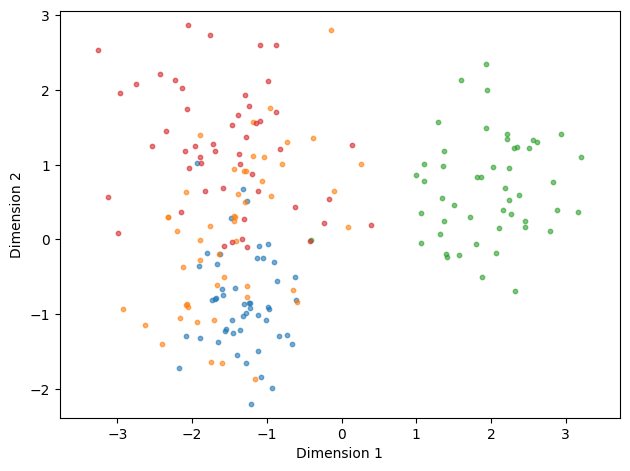

In [9]:
plot_first_two_dims(clouds)

Text(0, 0.5, 'Dimension 4')

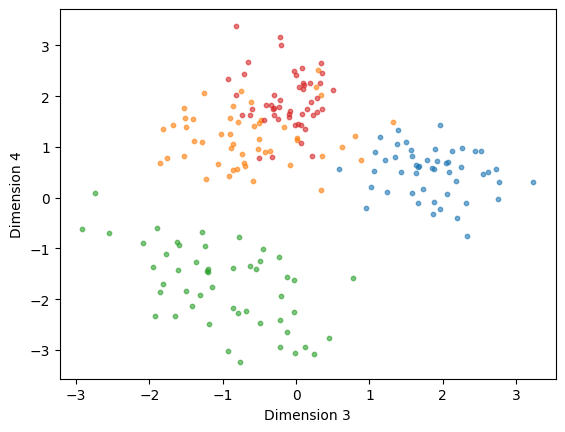

In [9]:
    for cloud in clouds:
        plt.scatter(cloud[:, 2], cloud[:, 3], s=10, alpha=0.6)
    plt.xlabel('Dimension 3')
    plt.ylabel('Dimension 4')

In [ ]:
epsilon = 1e-3
num_clouds = 5
cloud_size_arr = []
accs_arr = []

for i in range (5):
    for cloud_size in range(10, 110, 10):
        clouds1, means1, covs1  = generate_point_clouds(num_clouds, cloud_size, 10, A=2, B=0.5)
        clouds2 = resample_point_clouds(means1, covs1, cloud_size)
        dset1, labels1 = flatten_clouds(clouds1)
        dset2, labels2 = flatten_clouds(clouds2)
        gw = run_ot(dset1, dset2, num_clouds * cloud_size)
        acc = compute_mapping_acc(gw, labels1, labels2)

        cloud_size_arr.append(cloud_size)
        accs_arr.append(acc)

/n/holylabs/mooney_lab/Lab/joshprice/speciesOT/speciesOT_env/lib/python3.12/site-packages/ot/bregman/_sinkhorn.py:667: UserWarning: Sinkhorn did not converge. You might want to increase the number of iterations `numItermax` or the regularization parameter `reg`.
  warnings.warn(
/n/holylabs/mooney_lab/Lab/joshprice/speciesOT/speciesOT_env/lib/python3.12/site-packages/ot/backend.py:1168: RuntimeWarning: divide by zero encountered in log
  return np.log(a)
/n/holylabs/mooney_lab/Lab/joshprice/speciesOT/speciesOT_env/lib/python3.12/site-packages/ot/bregman/_sinkhorn.py:667: UserWarning: Sinkhorn did not converge. You might want to increase the number of iterations `numItermax` or the regularization parameter `reg`.
  warnings.warn(
/n/holylabs/mooney_lab/Lab/joshprice/speciesOT/speciesOT_env/lib/python3.12/site-packages/ot/backend.py:1168: RuntimeWarning: divide by zero encountered in log
  return np.log(a)
/n/holylabs/mooney_lab/Lab/joshprice/speciesOT/speciesOT_env/lib/python3.12/site-p

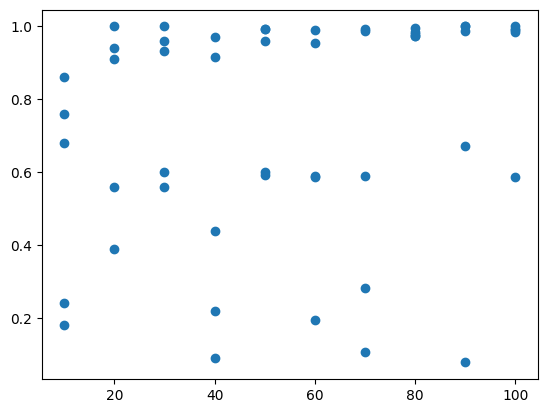

In [109]:
plt.plot(cloud_size_arr, accs_arr, 'o')

In [113]:
def plot_mean_std(df, x="cloud size", y="accuracy"):
    stats = df.groupby(x)[y].agg(["mean", "std"]).reset_index()

    plt.plot(stats[x], stats["mean"], marker="o")
    plt.fill_between(
        stats[x],
        stats["mean"] - stats["std"],
        stats["mean"] + stats["std"],
        alpha=0.3
    )

    plt.xlabel(x)
    plt.ylabel(y)
    plt.tight_layout()
    plt.show()

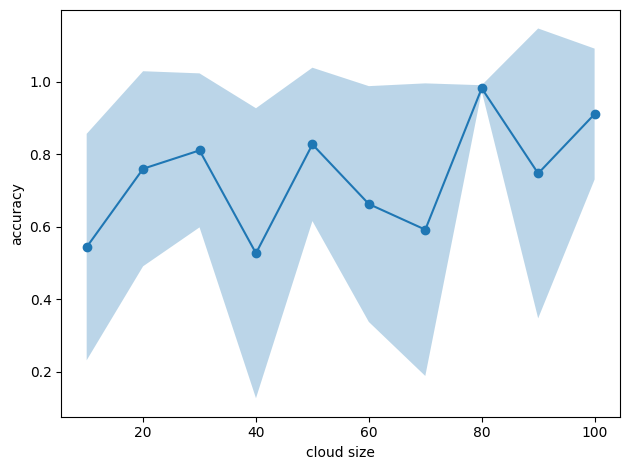

In [116]:
plot_mean_std(varying_pop_df)
#plt.plot(cloud_size_arr, accs_arr, 'o')

In [110]:
varying_pop_df = pd.DataFrame([cloud_size_arr, accs_arr]).T

In [111]:
varying_pop_df.columns = ['cloud size', 'accuracy']

In [112]:
varying_pop_df.to_csv('data/varying_cloud_size_5_pops_010725.csv')

In [188]:
clouds2 = resample_point_clouds(means, covs, 50)

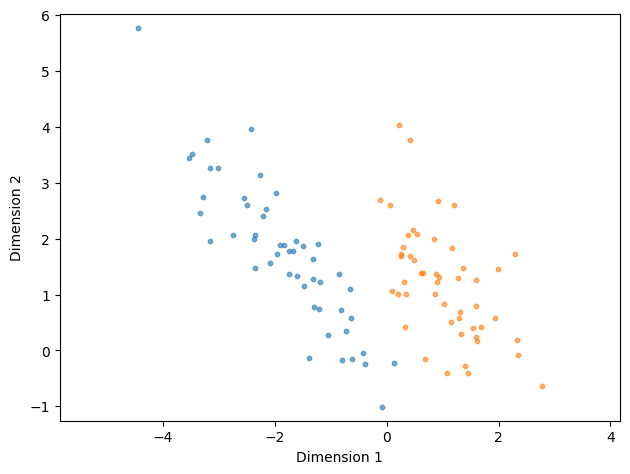

In [189]:
plot_first_two_dims(clouds2)

In [163]:
dset1, labels1 = flatten_clouds(clouds)

In [164]:
dset2, labels2 = flatten_clouds(clouds2)

In [166]:
n_samples = dset1.shape[0]

In [167]:
xs = dset1
xt = dset2
C1 = sp.spatial.distance.cdist(xs, xs)
C2 = sp.spatial.distance.cdist(xt, xt)

C1 /= C1.max()
C2 /= C2.max()


p = ot.unif(n_samples)
q = ot.unif(n_samples)

# Proximal Point algorithm with Kullback-Leibler as proximal operator
gw, log = ot.gromov.entropic_gromov_wasserstein(
C1, C2, p, q, "square_loss", epsilon=epsilon, solver="PPA", log=True)

/n/holylabs/mooney_lab/Lab/joshprice/speciesOT/speciesOT_env/lib/python3.12/site-packages/ot/bregman/_sinkhorn.py:667: UserWarning: Sinkhorn did not converge. You might want to increase the number of iterations `numItermax` or the regularization parameter `reg`.
  warnings.warn(
/n/holylabs/mooney_lab/Lab/joshprice/speciesOT/speciesOT_env/lib/python3.12/site-packages/ot/backend.py:1168: RuntimeWarning: divide by zero encountered in log
  return np.log(a)


In [174]:
compute_mapping_acc(gw, labels1, labels2)

0.76

### Varying number of 2D populations (2-10)

In [36]:
epsilon = 1e-3
num_clouds_arr = []
accs_arr = []
cloud_size = 20

for i in range(5):
    for num_clouds in [2,3,4,5,6,8,10]:
        clouds1, means1, covs1 = generate_point_clouds(num_clouds, cloud_size, 2, A=2, B=0.5)
        clouds2 = resample_point_clouds(means1, covs1, cloud_size)
        dset1, labels1 = flatten_clouds(clouds1)
        dset2, labels2 = flatten_clouds(clouds2)
        gw = run_ot(dset1, dset2, num_clouds * cloud_size)
        acc = compute_mapping_acc(gw, labels1, labels2)

        num_clouds_arr.append(num_clouds)
        accs_arr.append(acc)

/n/holylabs/mooney_lab/Lab/joshprice/speciesOT/speciesOT_env/lib/python3.12/site-packages/ot/bregman/_sinkhorn.py:667: UserWarning: Sinkhorn did not converge. You might want to increase the number of iterations `numItermax` or the regularization parameter `reg`.
  warnings.warn(
/n/holylabs/mooney_lab/Lab/joshprice/speciesOT/speciesOT_env/lib/python3.12/site-packages/ot/backend.py:1168: RuntimeWarning: divide by zero encountered in log
  return np.log(a)
/n/holylabs/mooney_lab/Lab/joshprice/speciesOT/speciesOT_env/lib/python3.12/site-packages/ot/bregman/_sinkhorn.py:667: UserWarning: Sinkhorn did not converge. You might want to increase the number of iterations `numItermax` or the regularization parameter `reg`.
  warnings.warn(
/n/holylabs/mooney_lab/Lab/joshprice/speciesOT/speciesOT_env/lib/python3.12/site-packages/ot/backend.py:1168: RuntimeWarning: divide by zero encountered in log
  return np.log(a)
/n/holylabs/mooney_lab/Lab/joshprice/speciesOT/speciesOT_env/lib/python3.12/site-p

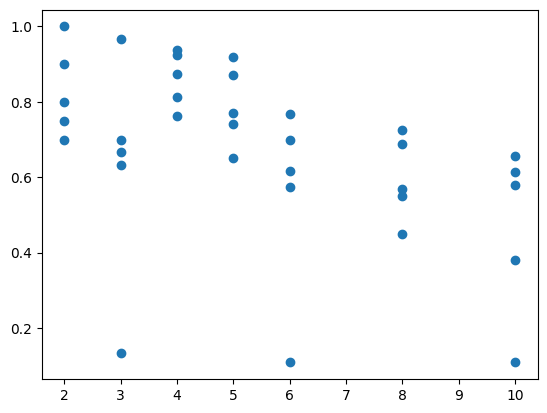

In [37]:
plt.plot(num_clouds_arr, accs_arr, 'o')

In [38]:
varying_clouds_df = pd.DataFrame([num_clouds_arr, accs_arr]).T

In [39]:
varying_clouds_df.columns = ['cloud count', 'accuracy']

In [40]:
varying_clouds_df.to_csv('data/varying_cloud_count_010725.csv')

In [54]:
### Varying number of dimensions (2-50)
epsilon = 1e-3
num_dims_arr = []
accs_arr = []
cloud_size = 20
num_clouds = 5

for i in range(5):
    for num_dims in [2,5,10,20,30,40,50]:
        clouds1, means1, covs1 = generate_point_clouds(num_clouds, cloud_size, num_dims, A=2, B=0.5)
        clouds2 = resample_point_clouds(means1, covs1, cloud_size)
        dset1, labels1 = flatten_clouds(clouds1)
        dset2, labels2 = flatten_clouds(clouds2)
        gw = run_ot(dset1, dset2, num_clouds * cloud_size)
        acc = compute_mapping_acc(gw, labels1, labels2)

        num_dims_arr.append(num_dims)
        accs_arr.append(acc)

/n/holylabs/mooney_lab/Lab/joshprice/speciesOT/speciesOT_env/lib/python3.12/site-packages/ot/bregman/_sinkhorn.py:667: UserWarning: Sinkhorn did not converge. You might want to increase the number of iterations `numItermax` or the regularization parameter `reg`.
  warnings.warn(
/n/holylabs/mooney_lab/Lab/joshprice/speciesOT/speciesOT_env/lib/python3.12/site-packages/ot/backend.py:1168: RuntimeWarning: divide by zero encountered in log
  return np.log(a)
/n/holylabs/mooney_lab/Lab/joshprice/speciesOT/speciesOT_env/lib/python3.12/site-packages/ot/bregman/_sinkhorn.py:667: UserWarning: Sinkhorn did not converge. You might want to increase the number of iterations `numItermax` or the regularization parameter `reg`.
  warnings.warn(
/n/holylabs/mooney_lab/Lab/joshprice/speciesOT/speciesOT_env/lib/python3.12/site-packages/ot/backend.py:1168: RuntimeWarning: divide by zero encountered in log
  return np.log(a)
/n/holylabs/mooney_lab/Lab/joshprice/speciesOT/speciesOT_env/lib/python3.12/site-p

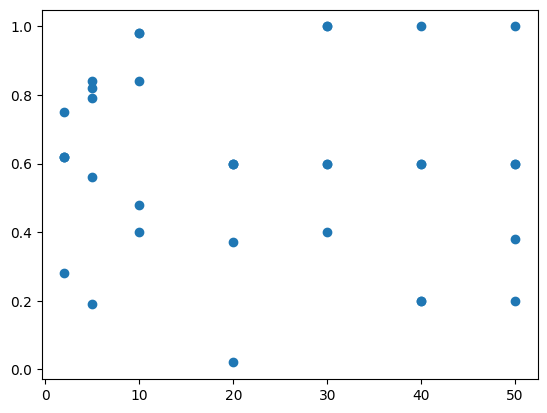

In [55]:
plt.plot(num_dims_arr, accs_arr, 'o')

In [56]:
varying_dims_df = pd.DataFrame([num_dims_arr, accs_arr]).T
varying_dims_df.columns = ['dimensions', 'accuracy']
varying_dims_df.to_csv('data/varying_dim_count_010725.csv')

In [41]:
# improving figure on 1/20/25
varying_dims_df = pd.read_csv('data/varying_dim_count_010725.csv')

Text(0.5, 1.0, 'Accuracy vs number of dimensions')

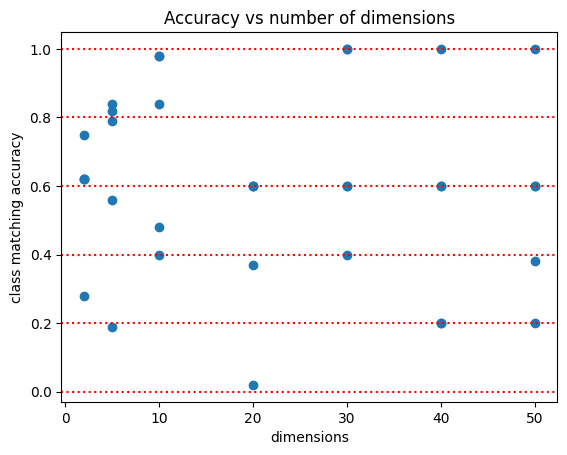

In [56]:
num_dims_arr = varying_dims_df['dimensions'].tolist()
accs_arr = varying_dims_df['accuracy'].tolist()
plt.plot(num_dims_arr, accs_arr, 'o')
plt.axhline(y=0, color='r', linestyle=':')
plt.axhline(y=0.2, color='r', linestyle=':')
plt.axhline(y=0.4, color='r', linestyle=':')
plt.axhline(y=0.6, color='r', linestyle=':')
plt.axhline(y=0.8, color='r', linestyle=':')
plt.axhline(y=1, color='r', linestyle=':')
plt.xlabel('dimensions')
plt.ylabel('class matching accuracy')
plt.title('Accuracy vs number of dimensions')

In [69]:
### Varying number of dimensions (2-50) with GEODESIC distance (k=3)
epsilon = 1e-3
num_dims_arr = []
accs_arr = []
cloud_size = 10
num_clouds = 5
k=11

for i in range(5):
    for num_dims in [2,10,50]:
        clouds1, means1, covs1 = generate_point_clouds(num_clouds, cloud_size, num_dims, A=2, B=0.5)
        clouds2 = resample_point_clouds(means1, covs1, cloud_size)
        dset1, labels1 = flatten_clouds(clouds1)
        dset2, labels2 = flatten_clouds(clouds2)
        gw = run_ot(dset1, dset2, num_clouds * cloud_size, distance_method='geodesic', knn_k=k)
        acc = compute_mapping_acc(gw, labels1, labels2)

        num_dims_arr.append(num_dims)
        accs_arr.append(acc)

/n/holylabs/mooney_lab/Lab/joshprice/speciesOT/speciesOT_env/lib/python3.12/site-packages/ot/bregman/_sinkhorn.py:667: UserWarning: Sinkhorn did not converge. You might want to increase the number of iterations `numItermax` or the regularization parameter `reg`.
  warnings.warn(
/n/holylabs/mooney_lab/Lab/joshprice/speciesOT/speciesOT_env/lib/python3.12/site-packages/ot/backend.py:1168: RuntimeWarning: divide by zero encountered in log
  return np.log(a)
/n/holylabs/mooney_lab/Lab/joshprice/speciesOT/speciesOT_env/lib/python3.12/site-packages/ot/bregman/_sinkhorn.py:667: UserWarning: Sinkhorn did not converge. You might want to increase the number of iterations `numItermax` or the regularization parameter `reg`.
  warnings.warn(
/n/holylabs/mooney_lab/Lab/joshprice/speciesOT/speciesOT_env/lib/python3.12/site-packages/ot/backend.py:1168: RuntimeWarning: divide by zero encountered in log
  return np.log(a)
/n/holylabs/mooney_lab/Lab/joshprice/speciesOT/speciesOT_env/lib/python3.12/site-p

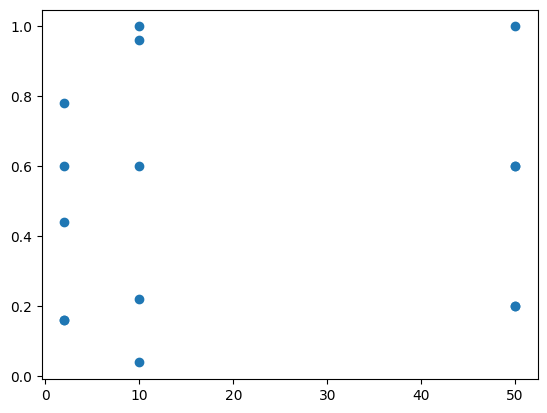

In [70]:
plt.plot(num_dims_arr, accs_arr, 'o')

In [ ]:
varying_dims_geodesic_df = pd.DataFrame([num_dims_arr, accs_arr]).T
varying_dims_geodesic_df.columns = ['dimensions', 'accuracy']
varying_dims_geodesic_df.to_csv('data/varying_dim_count_geodesic_010725.csv')

In [74]:
# Visualizing graphs

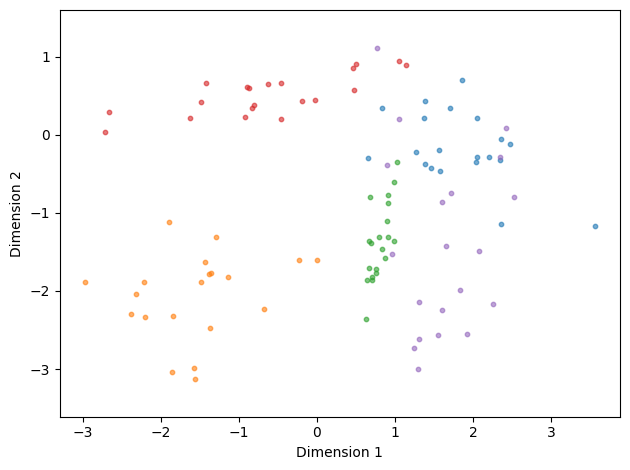

In [98]:
clouds1, means1, covs1 = generate_point_clouds(5, 20, 2, A=2, B=0.5)
plot_first_two_dims(clouds1)

In [100]:
cloud_coords, labels = flatten_clouds(clouds1)

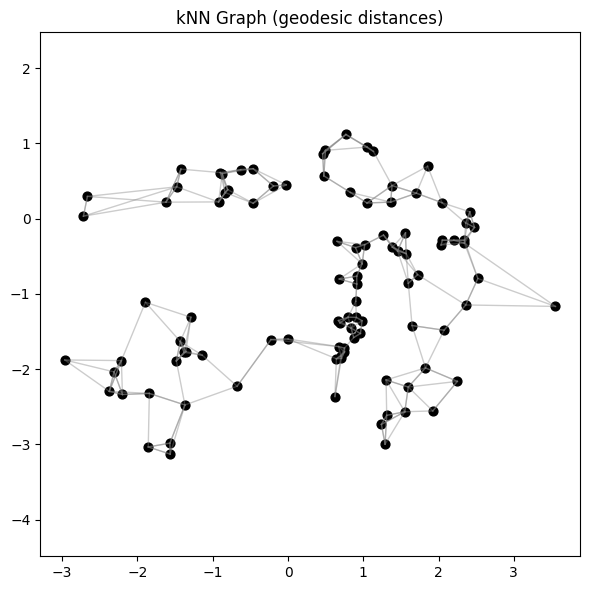

array([[0.        , 0.0415731 , 0.23819795, ..., 0.22270485, 0.13919644,
        0.25226315],
       [0.0415731 , 0.        , 0.22890196, ..., 0.21677485, 0.18076954,
        0.24296715],
       [0.23819795, 0.22890196, 0.        , ..., 0.24715811, 0.3773944 ,
        0.014387  ],
       ...,
       [0.22270485, 0.21677485, 0.24715811, ..., 0.        , 0.36190129,
        0.2612233 ],
       [0.13919644, 0.18076954, 0.3773944 , ..., 0.36190129, 0.        ,
        0.39145959],
       [0.25226315, 0.24296715, 0.014387  , ..., 0.2612233 , 0.39145959,
        0.        ]], shape=(100, 100))

In [101]:
knn_geodesic_distance_matrix(cloud_coords, k=3, visualize=True)

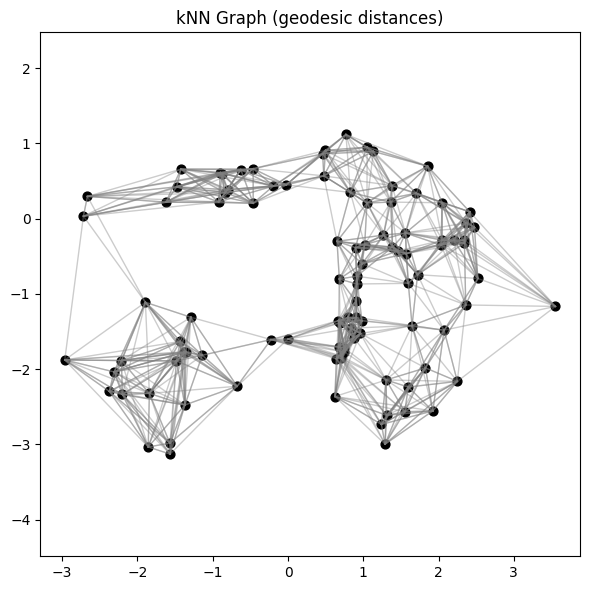

array([[0.        , 0.04367658, 0.16446502, ..., 0.31027077, 0.21019102,
        0.18787833],
       [0.04367658, 0.        , 0.12078844, ..., 0.30272467, 0.2429746 ,
        0.14420175],
       [0.16446502, 0.12078844, 0.        , ..., 0.36065561, 0.34472954,
        0.02341331],
       ...,
       [0.31027077, 0.30272467, 0.36065561, ..., 0.        , 0.10506182,
        0.38198154],
       [0.21019102, 0.2429746 , 0.34472954, ..., 0.10506182, 0.        ,
        0.36605547],
       [0.18787833, 0.14420175, 0.02341331, ..., 0.38198154, 0.36605547,
        0.        ]], shape=(100, 100))

In [102]:
knn_geodesic_distance_matrix(cloud_coords, k=11, visualize=True)

In [103]:
clouds2 = resample_point_clouds(means1, covs1, 20)
dset1, labels1 = flatten_clouds(clouds1)
dset2, labels2 = flatten_clouds(clouds2)
gw = run_ot(dset1, dset2, 5 * 20, visualize=True)
acc = compute_mapping_acc(gw, labels1, labels2)

/n/holylabs/mooney_lab/Lab/joshprice/speciesOT/speciesOT_env/lib/python3.12/site-packages/ot/bregman/_sinkhorn.py:667: UserWarning: Sinkhorn did not converge. You might want to increase the number of iterations `numItermax` or the regularization parameter `reg`.
  warnings.warn(
/n/holylabs/mooney_lab/Lab/joshprice/speciesOT/speciesOT_env/lib/python3.12/site-packages/ot/backend.py:1168: RuntimeWarning: divide by zero encountered in log
  return np.log(a)


In [104]:
acc

0.81

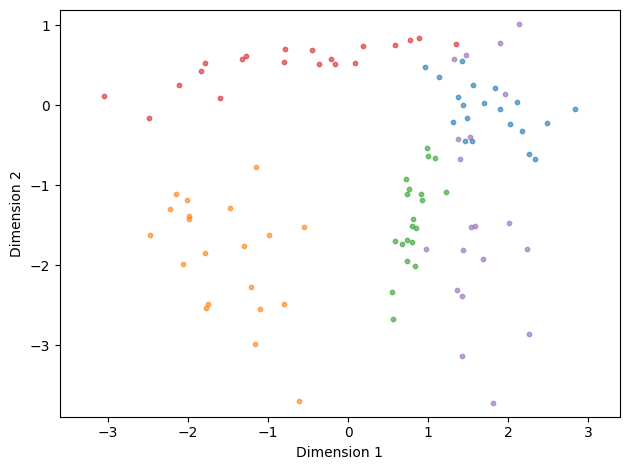

In [105]:
plot_first_two_dims(clouds2)

### Influence of k and entropy parameter in mapping geodesic distance.

In [71]:
eps_k_acc_df = pd.DataFrame(columns=['epsilon','k','accuracy'])
accs_arr = []
cloud_size = 10
num_clouds = 5
num_dims = 50

for i in range(5):
    for epsilon in [10, 1, 1e-1, 1e-2, 1e-3]:
        for k in [5, 10, 20, 30, 50]:
            clouds1, means1, covs1 = generate_point_clouds(num_clouds, cloud_size, num_dims, A=2, B=0.5)
            clouds2 = resample_point_clouds(means1, covs1, cloud_size)
            dset1, labels1 = flatten_clouds(clouds1)
            dset2, labels2 = flatten_clouds(clouds2)
            acc = compute_mapping_acc(gw, labels1, labels2)

            eps_k_acc_df.loc[len(eps_k_acc_df)] = [epsilon, k, acc]

/n/holylabs/mooney_lab/Lab/joshprice/speciesOT/speciesOT_env/lib/python3.12/site-packages/ot/bregman/_sinkhorn.py:667: UserWarning: Sinkhorn did not converge. You might want to increase the number of iterations `numItermax` or the regularization parameter `reg`.
  warnings.warn(


KeyboardInterrupt: 

In [ ]:
eps_k_acc_df

In [ ]:
agg_df = (
    eps_k_acc_df
    .groupby(["epsilon", "k"], as_index=False)
    .agg(
        mean_accuracy=("accuracy", "mean"),
        std_accuracy=("accuracy", "std"),
        n=("accuracy", "size"),
    )
)

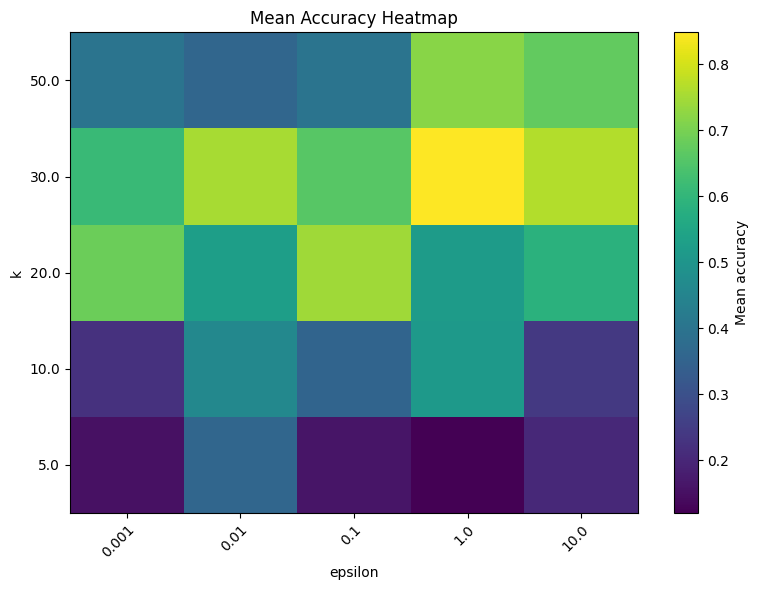

In [32]:
heat = agg_df.pivot(index="k", columns="epsilon", values="mean_accuracy")

# If epsilon / k are numeric and you want sorted axes:
heat = heat.sort_index(axis=0).sort_index(axis=1)

# 3) Plot heatmap (matplotlib only)
fig, ax = plt.subplots(figsize=(8, 6))
im = ax.imshow(heat.values, aspect="auto", origin="lower")

ax.set_title("Mean Accuracy Heatmap")
ax.set_xlabel("epsilon")
ax.set_ylabel("k")

# Put tick labels at the cell centers
ax.set_xticks(range(heat.shape[1]))
ax.set_yticks(range(heat.shape[0]))
ax.set_xticklabels(heat.columns)
ax.set_yticklabels(heat.index)

# Optional: rotate x tick labels if many epsilons
plt.setp(ax.get_xticklabels(), rotation=45, ha="right", rotation_mode="anchor")

# Colorbar
cbar = fig.colorbar(im, ax=ax)
cbar.set_label("Mean accuracy")

plt.tight_layout()
plt.show()

In [36]:
clouds1.shape

(5, 10, 50)

In [42]:
from scipy.stats import gaussian_kde
def plot_kdes(X):

    n_pops, n_cells, _ = X.shape
    dims_to_plot = 10

    fig, axes = plt.subplots(2, 5, figsize=(15, 6), sharey=True)
    axes = axes.ravel()

    for d in range(dims_to_plot):
        ax = axes[d]

        # Per-population KDEs
        for p in range(n_pops):
            data = X[p, :, d]
            kde = gaussian_kde(data)
            xgrid = np.linspace(data.min(), data.max(), 200)
            ax.plot(xgrid, kde(xgrid), alpha=0.7, label=f"pop {p}" if d == 0 else None)

        # Overall KDE (all populations pooled)
        all_data = X[:, :, d].reshape(-1)
        kde_all = gaussian_kde(all_data)
        xgrid_all = np.linspace(all_data.min(), all_data.max(), 300)
        ax.plot(xgrid_all, kde_all(xgrid_all), color="black", lw=2.5,
                label="all" if d == 0 else None)

        ax.set_title(f"Dimension {d}")

    axes[0].legend(frameon=False)
    plt.tight_layout()
    plt.show()


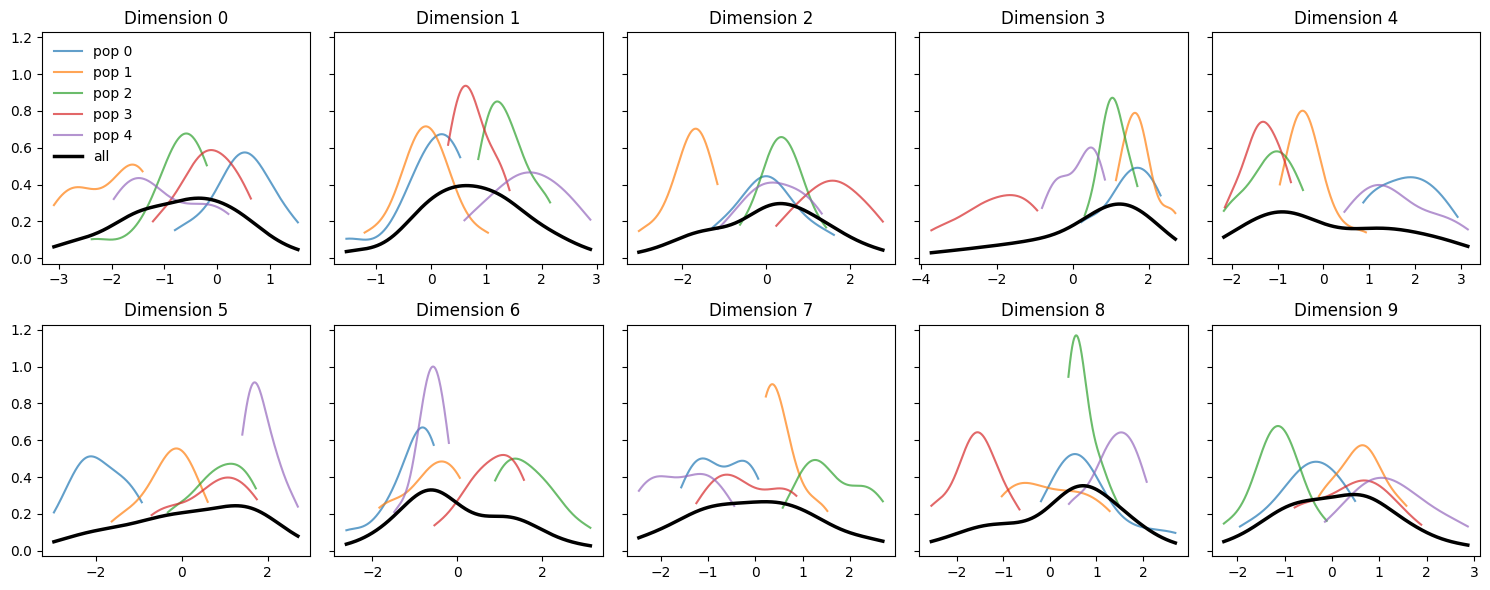

In [43]:
plot_kdes(clouds1)

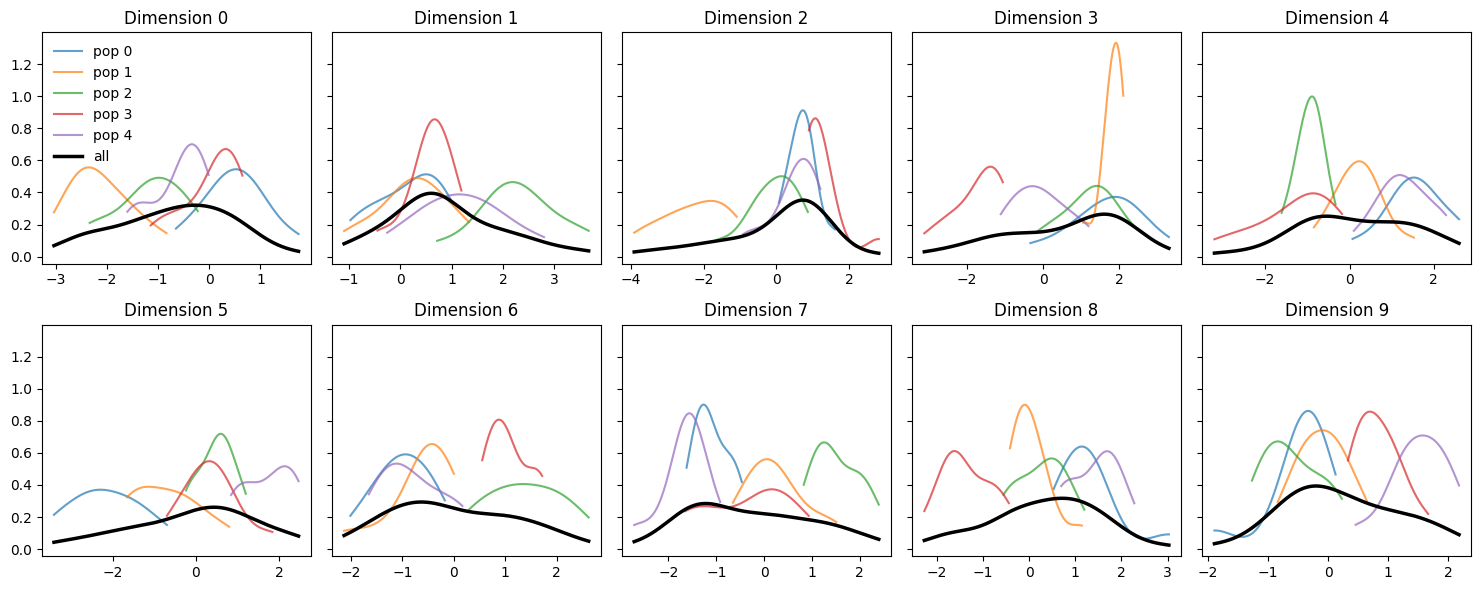

In [44]:
plot_kdes(clouds2)

In [46]:
def bic_1v2_first_dims(X, dims=10, covariance_type="full", random_state=0, n_init=10):
    X = np.asarray(X)
    n_pops, n_cells, n_dims = X.shape
    dims = min(dims, n_dims)

    out = np.full((dims, 2), np.nan)  # columns: [BIC1, BIC2]

    for d in range(dims):
        x = X[:, :, d].reshape(-1, 1)          # pool all populations for this dimension
        x = x[np.isfinite(x).ravel()]          # drop NaN/inf if any
        x = x.reshape(-1, 1)

        if x.shape[0] < 3 or np.unique(x).size < 2:
            continue

        gmm1 = GaussianMixture(1, covariance_type=covariance_type,
                               random_state=random_state, n_init=n_init).fit(x)
        gmm2 = GaussianMixture(2, covariance_type=covariance_type,
                               random_state=random_state, n_init=n_init).fit(x)

        out[d, 0] = gmm1.bic(x)
        out[d, 1] = gmm2.bic(x)

    return out  # shape (dims, 2)


In [49]:
bicsA = bic_1v2_first_dims(clouds1, dims=10)

# bics[d] = [BIC1, BIC2] for dimension d
for d, (bic1, bic2) in enumerate(bicsA):
    print(f"dim {d:2d}: BIC1={bic1:.3f}, BIC2={bic2:.3f}, ΔBIC={bic1-bic2:.3f}")

dim  0: BIC1=156.163, BIC2=165.959, ΔBIC=-9.796
dim  1: BIC1=140.319, BIC2=152.293, ΔBIC=-11.974
dim  2: BIC1=175.120, BIC2=184.085, ΔBIC=-8.965
dim  3: BIC1=192.724, BIC2=187.177, ΔBIC=5.547
dim  4: BIC1=189.702, BIC2=186.267, ΔBIC=3.435
dim  5: BIC1=186.048, BIC2=189.897, ΔBIC=-3.849
dim  6: BIC1=170.380, BIC2=175.170, ΔBIC=-4.790
dim  7: BIC1=172.308, BIC2=182.923, ΔBIC=-10.616
dim  8: BIC1=168.296, BIC2=170.465, ΔBIC=-2.169
dim  9: BIC1=160.800, BIC2=171.755, ΔBIC=-10.955


In [50]:
bicsB = bic_1v2_first_dims(clouds2, dims=10)

# bics[d] = [BIC1, BIC2] for dimension d
for d, (bic1, bic2) in enumerate(bicsB):
    print(f"dim {d:2d}: BIC1={bic1:.3f}, BIC2={bic2:.3f}, ΔBIC={bic1-bic2:.3f}")

dim  0: BIC1=158.744, BIC2=167.307, ΔBIC=-8.563
dim  1: BIC1=155.632, BIC2=163.228, ΔBIC=-7.595
dim  2: BIC1=183.884, BIC2=176.428, ΔBIC=7.456
dim  3: BIC1=191.719, BIC2=189.947, ΔBIC=1.772
dim  4: BIC1=178.538, BIC2=186.950, ΔBIC=-8.411
dim  5: BIC1=188.208, BIC2=196.042, ΔBIC=-7.834
dim  6: BIC1=166.250, BIC2=171.649, ΔBIC=-5.399
dim  7: BIC1=172.335, BIC2=175.005, ΔBIC=-2.670
dim  8: BIC1=163.043, BIC2=173.319, ΔBIC=-10.275
dim  9: BIC1=142.385, BIC2=150.139, ΔBIC=-7.754


In [51]:
bicsA

array([[156.16325885, 165.95876882],
       [140.31906203, 152.29297232],
       [175.11974634, 184.08510407],
       [192.72424131, 187.17731875],
       [189.70210187, 186.26660753],
       [186.04829962, 189.89744919],
       [170.37969606, 175.17007958],
       [172.30750874, 182.92344693],
       [168.29636009, 170.46540887],
       [160.80008968, 171.75506614]])

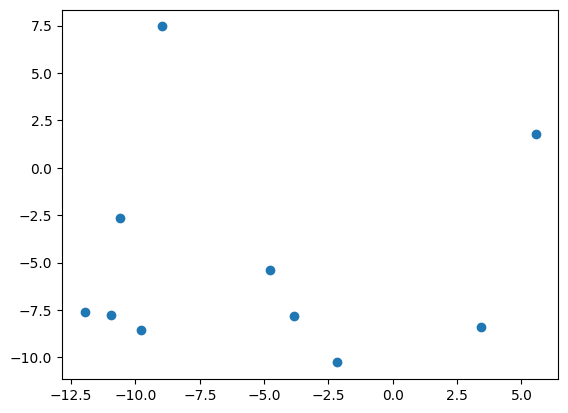

In [53]:
plt.scatter(bicsA[:,0]-bicsA[:,1], bicsB[:,0]-bicsB[:,1])

### Mapping geodesic distance with the 10 most bimodal dimensions

In [72]:
def top_dims_by_overall_delta_bic(X, top_n=10, dims_to_consider=None,
                                 covariance_type="full", random_state=0, n_init=10):
    """
    X: (n_pops, n_cells, n_dims)
    Ranks dimensions by overall ΔBIC = BIC1 - BIC2 computed on pooled data
    (all populations combined), then returns X sliced to the top_n dims.

    Returns:
      X_top:  (n_pops, n_cells, top_n)
      top_ix: (top_n,) indices of selected dimensions (sorted by decreasing ΔBIC)
      deltas: (n_dims_considered,) ΔBIC per dimension (NaN if not computable)
    """
    X = np.asarray(X)
    n_pops, n_cells, n_dims = X.shape

    if dims_to_consider is None:
        dims_to_consider = n_dims
    dims_to_consider = min(dims_to_consider, n_dims)

    deltas = np.full(dims_to_consider, np.nan)

    for d in range(dims_to_consider):
        x = X[:, :, d].reshape(-1, 1)
        x = x[np.isfinite(x).ravel()]
        x = x.reshape(-1, 1)

        # Need enough data + variability to fit 2 components
        if x.shape[0] < 5 or np.unique(x).size < 2:
            continue

        g1 = GaussianMixture(1, covariance_type=covariance_type,
                             random_state=random_state, n_init=n_init).fit(x)
        g2 = GaussianMixture(2, covariance_type=covariance_type,
                             random_state=random_state, n_init=n_init).fit(x)

        deltas[d] = g1.bic(x) - g2.bic(x)  # ΔBIC (overall)

    # Pick top dims (ignore NaNs)
    valid = np.isfinite(deltas)
    if not np.any(valid):
        raise ValueError("No dimensions produced a finite ΔBIC (check data variability / NaNs).")

    order = np.argsort(deltas[valid])[::-1]  # descending
    valid_ix = np.where(valid)[0]
    top_ix = valid_ix[order[:min(top_n, order.size)]]

    X_top = X[:, :, top_ix]  # (n_pops, n_cells, top_n)
    return X_top, top_ix, deltas

# Example usage:
# X_top, top_dims, deltas = top_dims_by_overall_delta_bic(X, top_n=10)
# print("Top dims:", top_dims)
# print("Top ΔBICs:", deltas[top_dims])
# X_top.shape  # -> (5, 10, 10)


In [73]:
eps_k_acc_df = pd.DataFrame(columns=['epsilon','k','accuracy'])
accs_arr = []
cloud_size = 10
num_clouds = 5
num_dims = 50
top_n=10

for i in range(5):
    for epsilon in [10, 1, 1e-1, 1e-2, 1e-3]:
        for k in [5, 10, 20, 30, 50]:
            clouds1, means1, covs1 = generate_point_clouds(num_clouds, cloud_size, num_dims, A=2, B=0.5)
            clouds2 = resample_point_clouds(means1, covs1, cloud_size)
            clouds1_top10, _, _ = top_dims_by_overall_delta_bic(clouds1, top_n=top_n)
            clouds2_top10, _, _ = top_dims_by_overall_delta_bic(clouds2, top_n=top_n)
            dset1, labels1 = flatten_clouds(clouds1_top10)
            dset2, labels2 = flatten_clouds(clouds2_top10)
            gw = run_ot(dset1, dset2, num_clouds * cloud_size, distance_method='geodesic', knn_k=k)
            acc = compute_mapping_acc(gw, labels1, labels2)

            eps_k_acc_df.loc[len(eps_k_acc_df)] = [epsilon, k, acc]

/n/holylabs/mooney_lab/Lab/joshprice/speciesOT/speciesOT_env/lib/python3.12/site-packages/ot/bregman/_sinkhorn.py:667: UserWarning: Sinkhorn did not converge. You might want to increase the number of iterations `numItermax` or the regularization parameter `reg`.
  warnings.warn(
/n/holylabs/mooney_lab/Lab/joshprice/speciesOT/speciesOT_env/lib/python3.12/site-packages/ot/bregman/_sinkhorn.py:667: UserWarning: Sinkhorn did not converge. You might want to increase the number of iterations `numItermax` or the regularization parameter `reg`.
  warnings.warn(
/n/holylabs/mooney_lab/Lab/joshprice/speciesOT/speciesOT_env/lib/python3.12/site-packages/ot/bregman/_sinkhorn.py:667: UserWarning: Sinkhorn did not converge. You might want to increase the number of iterations `numItermax` or the regularization parameter `reg`.
  warnings.warn(
/n/holylabs/mooney_lab/Lab/joshprice/speciesOT/speciesOT_env/lib/python3.12/site-packages/ot/bregman/_sinkhorn.py:667: UserWarning: Sinkhorn did not converge. Y

In [74]:
agg_df = (
    eps_k_acc_df
    .groupby(["epsilon", "k"], as_index=False)
    .agg(
        mean_accuracy=("accuracy", "mean"),
        std_accuracy=("accuracy", "std"),
        n=("accuracy", "size"),
    )
)

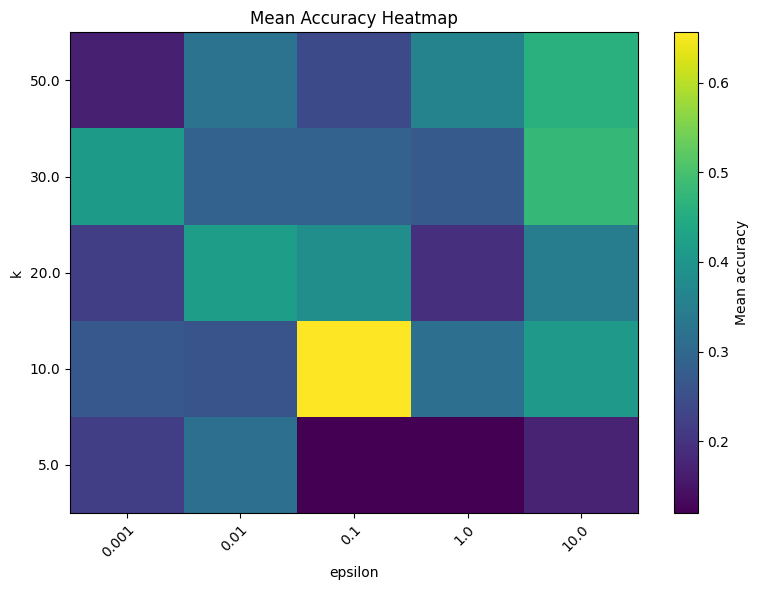

In [75]:
heat = agg_df.pivot(index="k", columns="epsilon", values="mean_accuracy")

# If epsilon / k are numeric and you want sorted axes:
heat = heat.sort_index(axis=0).sort_index(axis=1)

# 3) Plot heatmap (matplotlib only)
fig, ax = plt.subplots(figsize=(8, 6))
im = ax.imshow(heat.values, aspect="auto", origin="lower")

ax.set_title("Mean Accuracy Heatmap")
ax.set_xlabel("epsilon")
ax.set_ylabel("k")

# Put tick labels at the cell centers
ax.set_xticks(range(heat.shape[1]))
ax.set_yticks(range(heat.shape[0]))
ax.set_xticklabels(heat.columns)
ax.set_yticklabels(heat.index)

# Optional: rotate x tick labels if many epsilons
plt.setp(ax.get_xticklabels(), rotation=45, ha="right", rotation_mode="anchor")

# Colorbar
cbar = fig.colorbar(im, ax=ax)
cbar.set_label("Mean accuracy")

plt.tight_layout()
plt.show()

In [77]:
agg_df

,epsilon,k,mean_accuracy,std_accuracy,n
0,0.001,5.0,0.220,0.178885,5
1,0.001,10.0,0.268,0.252032,5
2,0.001,20.0,0.220,0.086023,5
3,0.001,30.0,0.412,0.351169,5
4,0.001,50.0,0.168,0.104499,5
5,0.010,5.0,0.316,0.226451,5
6,0.010,10.0,0.260,0.216333,5
7,0.010,20.0,0.420,0.345832,5
8,0.010,30.0,0.288,0.173551,5
9,0.010,50.0,0.324,0.248355,5


In [ ]:
# Compare best accuracies to L1 and L2 norm accuracies on 10 and 50 dims

### Visualizing trees in higher dimensions

In [38]:
clouds, means, covs = generate_point_clouds(4, 50, 50, A=2, B=0.5)

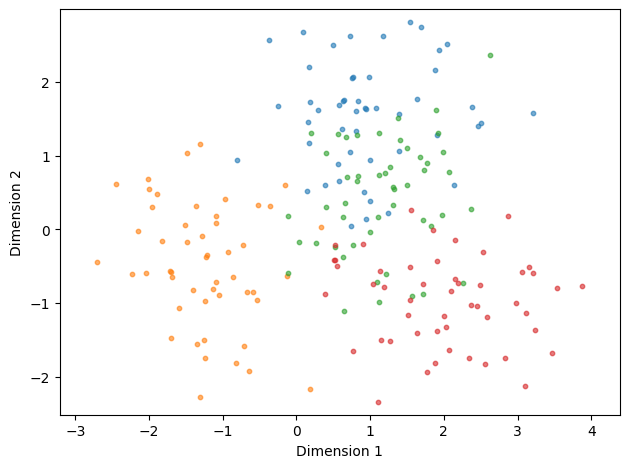

In [39]:
plot_first_two_dims(clouds)

In [40]:
cloud_coords, labels = flatten_clouds(clouds)

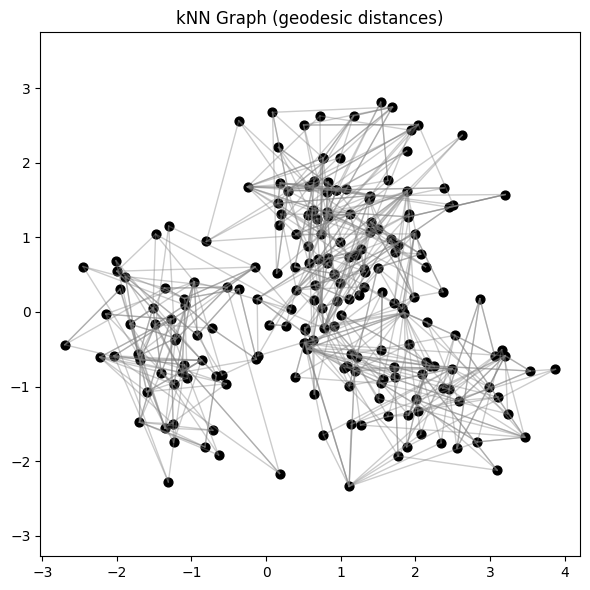

array([[0.        , 0.55113413, 0.54157722, ..., 1.        , 1.        ,
        1.        ],
       [0.55113413, 0.        , 0.71152557, ..., 1.        , 1.        ,
        1.        ],
       [0.54157722, 0.71152557, 0.        , ..., 1.        , 1.        ,
        1.        ],
       ...,
       [1.        , 1.        , 1.        , ..., 0.        , 0.5287803 ,
        0.72382898],
       [1.        , 1.        , 1.        , ..., 0.5287803 , 0.        ,
        0.39440268],
       [1.        , 1.        , 1.        , ..., 0.72382898, 0.39440268,
        0.        ]], shape=(200, 200))

In [41]:
knn_geodesic_distance_matrix(cloud_coords, k=3, visualize=True)

In [45]:
clouds2 = resample_point_clouds(means, covs, 50)

In [62]:
cloud_coords2, labels2 = flatten_clouds(clouds2)

In [59]:
gw = run_ot(cloud_coords, cloud_coords2, 200, epsilon=0.1)

(<Figure size 700x600 with 1 Axes>,
 <Axes: title={'center': 'GOT argmax matches (row-wise)'}, xlabel='dim 0', ylabel='dim 1'>,
 array([  7,  25,  41,  32,  29,   3,  30,   1,   0,  36,  23,  14,   5,
          8,  31,   6,  27,  40,  43,  46,  44,  24,  16,  48,  45,  47,
         13,  33,  49,  12,  18,  19,  39,  34,  26,   2,  10,  28,  11,
          4,  35,  37,  17,  22,   9,  42,  15,  20,  21,  38,  80,  56,
         96,  50,  94,  54,  74,  69,  78,  67,  64,  61,  85,  97,  84,
         89,  57,  88,  60,  55,  81,  76,  66,  93,  53,  68,  51,  79,
         77,  63,  58,  95,  52,  87,  65,  99,  92,  75,  59,  73,  86,
         83,  91,  82,  70,  98,  90,  72,  71,  62, 121, 104, 123, 113,
        126, 131, 137, 133, 115, 149, 135, 143, 118, 120, 146, 119, 125,
        107, 117, 144, 140, 110, 138, 129, 142, 128, 130, 145, 136, 116,
        124, 111, 134, 106, 108, 141, 103, 109, 139, 127, 112, 132, 114,
        147, 100, 102, 148, 122, 101, 105, 171, 159, 150, 177, 165, 1

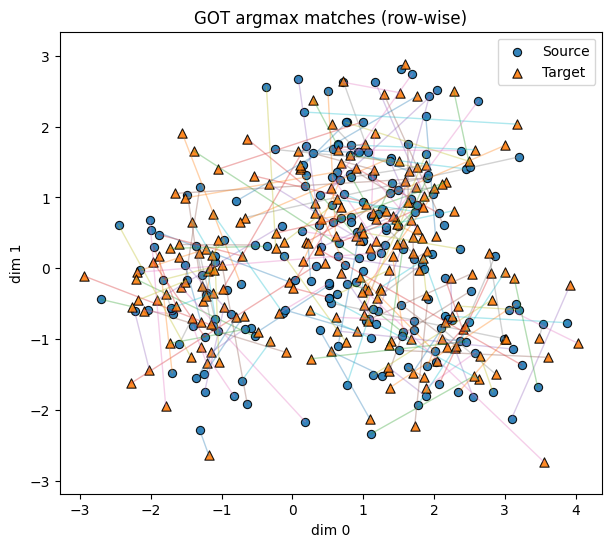

In [60]:
plot_got_best_matches(cloud_coords, cloud_coords2, gw)

(<Figure size 700x600 with 1 Axes>,
 <Axes: title={'center': 'GOT argmax matches with class consistency'}, xlabel='dim 0', ylabel='dim 1'>,
 array([  7,  25,  41,  32,  29,   3,  30,   1,   0,  36,  23,  14,   5,
          8,  31,   6,  27,  40,  43,  46,  44,  24,  16,  48,  45,  47,
         13,  33,  49,  12,  18,  19,  39,  34,  26,   2,  10,  28,  11,
          4,  35,  37,  17,  22,   9,  42,  15,  20,  21,  38,  80,  56,
         96,  50,  94,  54,  74,  69,  78,  67,  64,  61,  85,  97,  84,
         89,  57,  88,  60,  55,  81,  76,  66,  93,  53,  68,  51,  79,
         77,  63,  58,  95,  52,  87,  65,  99,  92,  75,  59,  73,  86,
         83,  91,  82,  70,  98,  90,  72,  71,  62, 121, 104, 123, 113,
        126, 131, 137, 133, 115, 149, 135, 143, 118, 120, 146, 119, 125,
        107, 117, 144, 140, 110, 138, 129, 142, 128, 130, 145, 136, 116,
        124, 111, 134, 106, 108, 141, 103, 109, 139, 127, 112, 132, 114,
        147, 100, 102, 148, 122, 101, 105, 171, 159, 150,

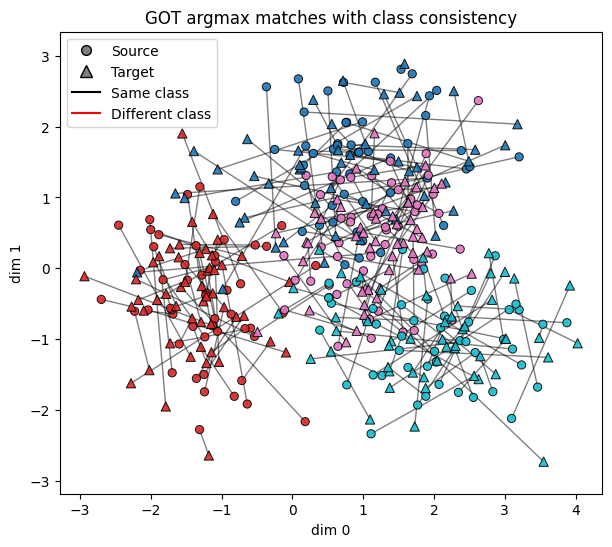

In [63]:
plot_got_best_matches_with_labels(cloud_coords, cloud_coords2, gw, labels, labels2)

In [ ]:
# 100% accuracy!

In [64]:
# Same with 2 dimensions
clouds1, means1, covs1 = generate_point_clouds(4, 50, 2, A=2, B=0.5)
cloud_coords1, labels1 = flatten_clouds(clouds1)
clouds2 = resample_point_clouds(means, covs, 50)
cloud_coords2, labels2 = flatten_clouds(clouds2)

In [65]:
gw = run_ot(cloud_coords1, cloud_coords2, 200, epsilon=0.1)

(<Figure size 700x600 with 1 Axes>,
 <Axes: title={'center': 'GOT argmax matches with class consistency'}, xlabel='dim 0', ylabel='dim 1'>,
 array([ 35,  51,  10, 139, 126,  28, 107,  34, 184,  44, 123, 196,  18,
        144,  41, 125, 129,  29,  21, 136, 110,  19,   7,  27,   4, 138,
         94, 141,   9, 126,  11, 117,  17, 106, 159, 149,  32,   5,  21,
        132,   8, 134, 123, 121, 112, 141,  14,   1,  11,  66, 138,  18,
        133, 105, 192, 154,  40, 119, 124,  16, 161, 151, 179,  31,  49,
        113,  82,  42,  60, 135,  37, 146,  61, 142,  13, 173, 197,  22,
         64,  73,  98,  42, 135,  17,  26,  39, 145, 148,  26,  81, 150,
        137,   6,  30,  28, 114,  96, 115,  84,  45, 187, 153, 185, 188,
        164, 152, 198, 102,  48,   0, 164, 194, 186,  15, 183, 186,  46,
        170, 193, 189, 190, 187, 147, 183,   3, 177, 180, 185, 181, 176,
        182, 178, 191, 198, 160, 155, 167, 165, 163, 174, 162, 166, 172,
         33,  38, 199,   4, 175,  24, 158,  83,  78,  53,

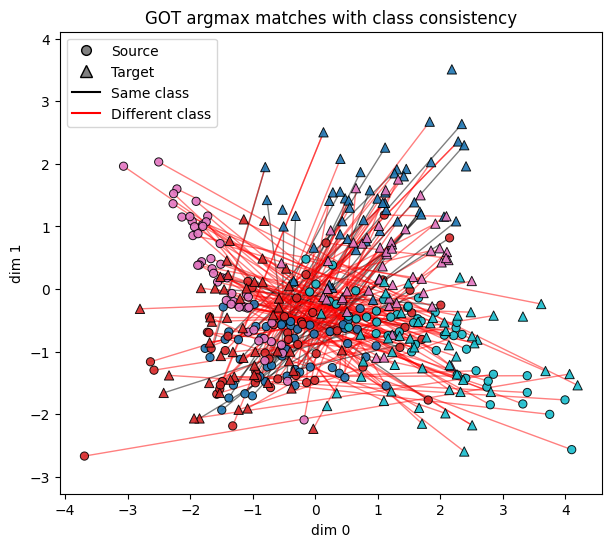

In [66]:
plot_got_best_matches_with_labels(cloud_coords1, cloud_coords2, gw, labels, labels2)

### Investigating the impact of anchoring a single point by making it an outlier

In [ ]:
# try with and without anchoring

In [30]:
clouds1, means1, covs1 = generate_point_clouds(4, 20, 2, A=2, B=0.5)
cloud_coords1, labels1 = flatten_clouds(clouds1)
clouds2 = resample_point_clouds(means1, covs1, 20)
cloud_coords2, labels2 = flatten_clouds(clouds2)

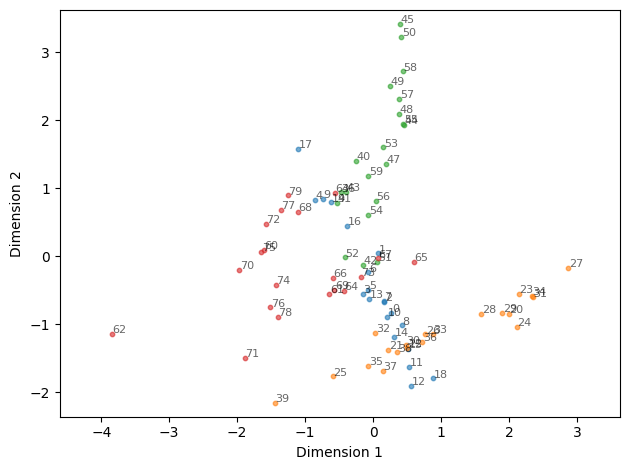

In [32]:
plot_first_two_dims(clouds1, annotate=True)

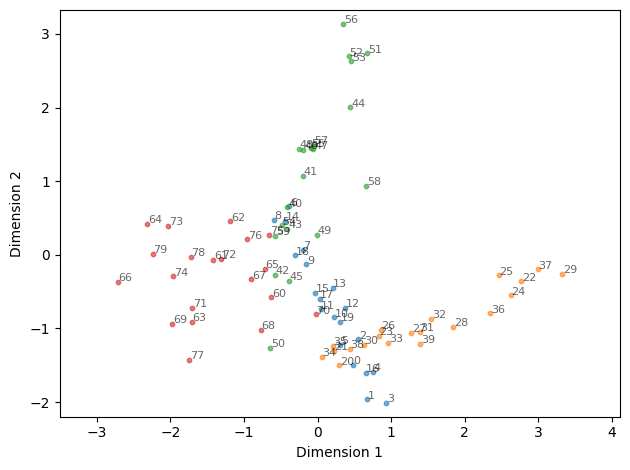

In [33]:
plot_first_two_dims(clouds2, annotate=True)

In [34]:
gw_anchored = run_ot_with_anchor(cloud_coords1, cloud_coords2, 80, 62, 66)

In [35]:
gw_unanchored = run_ot(cloud_coords1, cloud_coords2, 80)

Text(0.5, 1.0, 'GOT source and target pairings with anchor')

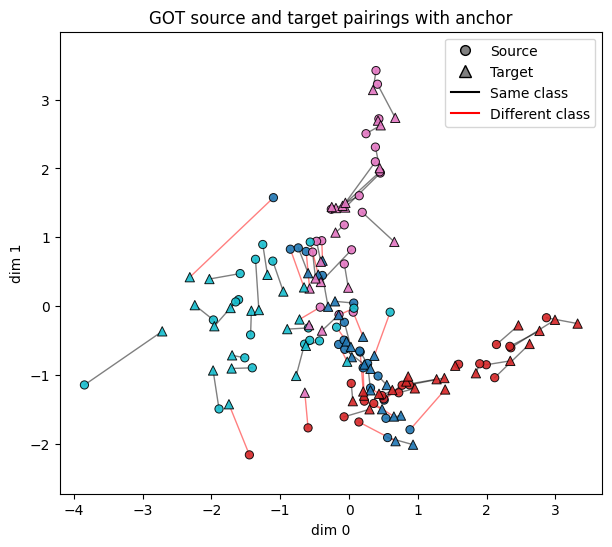

In [40]:
plot_got_best_matches_with_labels(cloud_coords1, cloud_coords2, gw_anchored, labels1, labels2)
plt.title("GOT source and target pairings with anchor")

Text(0.5, 1.0, 'GOT source and target pairings without anchor')

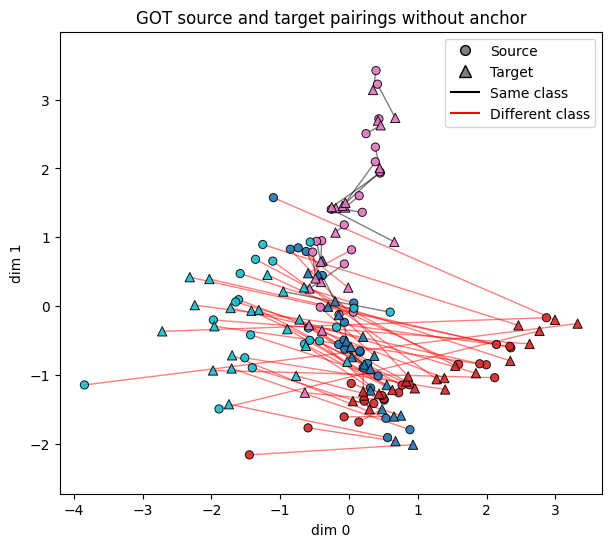

In [39]:
plot_got_best_matches_with_labels(cloud_coords1, cloud_coords2, gw_unanchored, labels1, labels2)
plt.title("GOT source and target pairings without anchor")

In [ ]:
# Considering fused GW
# Take most extreme points away from the population centroid for each class, label those as 